# Driven-dissipative Jaynes-Cummings model: photon-blockade breakdown

Companion notebook for **Sec. 4** of the QuantumFCS.jl manuscript.

A coherently driven cavity coupled to a two-level atom, in the rotating frame,
with cavity loss only:

$$
H = -\Delta\,(a^\dagger a + \sigma_+\sigma_-) + g\,(a^\dagger\sigma_- + a\,\sigma_+)
    - \mathcal{E}\,(a + a^\dagger),
\qquad
\dot\rho = -i[H,\rho] + \kappa\,\mathcal{D}[a]\rho .
$$

We count the **cavity emission** $\kappa\, a\rho a^\dagger$ and compute the first
three cumulants of the emitted-photon counting statistics: the count rate
$c_1/\kappa = \langle a^\dagger a\rangle$, the Fano factor
$\mathcal{F} = c_2/c_1$, and the skewness $\mathcal{G} = c_3/c_2^{3/2}$.

Sweeping the drive $x = 2\mathcal{E}/g$ at fixed $g/\kappa = 14$ crosses the
photon-blockade breakdown. On the detuned cuts the cavity becomes **bimodal**
(a dim, blockaded state coexisting with a bright, lasing-like one) and the
emission is strongly intermittent.

**What makes this hard.** The bright branch carries hundreds of photons, so the
Fock cutoff must grow with the drive: at $N = 500$ the Liouvillian is a
$\sim\!10^6 \times 10^6$ sparse non-Hermitian matrix. Worse, in the coexistence
region the usual boundary-population diagnostic can look perfectly converged
while the solver has locked onto the *wrong branch*. Cross-cutoff agreement of
the cumulants, not the tail, is the reliability gauge.

**What this notebook shows.** How the sweep is actually set up and driven
through the QuantumFCS API: how the trace-constrained steady state is solved,
how one incomplete-LU factorization is reused across drive points *and* handed
to the FCS Drazin solve, and how each point is gated on the exact identity
$c_1 = \kappa\langle a^\dagger a\rangle$.

By default the manuscript figure is rebuilt from the checked-in production data
and the live cells run a short, faithful segment of the sweep. Set
`RUN_FULL_JC = true` in the toggle cell to recompute the whole thing.

In [1]:
using DrWatson
# Locate this repository from the notebook's own position in the tree and
# activate its environment. This is deliberately independent of whichever
# project the editor happens to have selected, and `srcdir`/`datadir` below
# then always resolve inside this repository.
@quickactivate "QuantumFCSNotebooks"

using QuantumToolbox
using QuantumFCS
using Krylov, IncompleteLU          # enable the QuantumFCS iterative backend
using SparseArrays, LinearAlgebra
using DataFrames, Printf, Dates
using CairoMakie, LaTeXStrings

include(srcdir("jc_model.jl"))       # model + production pipeline
include(srcdir("data_io.jl"))        # checked-in datasets
include(srcdir("paper_figures.jl"))  # exact manuscript figures

CairoMakie.activate!(type = "png")
println("project : ", projectdir())
println("Julia ", VERSION, " | threads: ", Threads.nthreads())

  Activating project at `~/dev/QuantumFCS_paper_writing/QuantumFCS-Notebooks`
[ Info: Precompiling QuantumToolboxCairoMakieExt [d1882d82-aa0c-5fe6-8d67-350ca91d229b](cache misses: wrong dep version loaded (2))
[ Info: Precompiling QuantumToolboxCairoMakieExt [d1882d82-aa0c-5fe6-8d67-350ca91d229b] (cache misses: wrong dep version loaded (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


project : /Users/jano/dev/QuantumFCS_paper_writing/QuantumFCS-Notebooks
Julia 1.


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


12.6 | threads: 4


## Model

`jc_operators_for_cutoff(N)` builds the cavity+atom operators at Fock cutoff `N`
(Hilbert dimension $2(N+1)$) and returns the two Hamiltonian pieces we rescale
per point: the Jaynes-Cummings coupling $a^\dagger\sigma_- + a\sigma_+$ and the
drive $-(a + a^\dagger)$, together with the detuning operator
$a^\dagger a + \sigma_+\sigma_-$.

The Hamiltonian at a given point is then just a linear combination, which is
what lets a sweep rebuild `H` cheaply while keeping the operators fixed.

In [2]:
const g = 14.0     # Jaynes-Cummings coupling, in units of κ
const κ = 1.0      # cavity linewidth sets the unit

# Build the operators once for a given cutoff.
N_demo_cutoff = 150
ops = jc_operators_for_cutoff(N_demo_cutoff)

# Hamiltonian for one (Δ, E) point, and the single monitored jump.
jc_hamiltonian(ops, Δ, g, E) = -Δ * ops.detuning_op + g * ops.Hjc + E * ops.Hdr
cavity_loss = sqrt(κ) * ops.a

@printf("cutoff N = %d  ->  Hilbert dim = %d, Liouvillian %d x %d\n",
        N_demo_cutoff, 2*(N_demo_cutoff+1), (2*(N_demo_cutoff+1))^2, (2*(N_demo_cutoff+1))^2)

cutoff N = 150  ->  Hilbert dim = 302, Liouvillian 91204 x 91204


## One point, start to finish

This is the whole QuantumFCS call sequence for a single drive point.

1. `trace_constrained_system(L)` replaces the singular condition
   $\mathcal{L}\rho = 0$ with a non-singular linear system by imposing
   $\mathrm{tr}\,\rho = 1$.
2. `trace_constrained_steadystate(sys; method = :iterative, ...)` solves it with
   GMRES preconditioned by a shifted incomplete-LU factorization, and **returns
   that factorization** in `ss.Pl`.
3. `LindbladFCS(...; method = :iterative, Pl = ss.Pl)` hands the *same*
   factorization to the Drazin-inverse solves inside the cumulant recursion, so
   the point costs one factorization in total rather than two.

The counting data is the monitored jump list `mJ = [√κ a]` with weight
`nu = [1.0]`; `nC = 3` asks for the first three cumulants.

Finally we check the exact identity $c_1 = \kappa\langle a^\dagger a\rangle$:
the first cumulant of the emission counting statistics *is* the photon loss
rate. This is the acceptance gate used at every point of the production sweep.

In [3]:
Δ_demo, x_demo_point = 0.55, 0.60
E_demo = x_demo_point * g / 2

H   = jc_hamiltonian(ops, Δ_demo, g, E_demo)
L   = QuantumToolbox.liouvillian(H, [cavity_loss])
sys = trace_constrained_system(L)

# --- steady state (also produces the preconditioner we reuse below) ----------
t0 = time_ns()
ss = trace_constrained_steadystate(sys;
    method       = :iterative,
    τ            = 1e-1,      # ILU drop tolerance
    shift_factor = 1e-6,      # diagonal shift keeping the factorization stable
    rtol = 1e-10, atol = 1e-14, itmax = 120, memory = 60)
ss_seconds = (time_ns() - t0) / 1e9

ρss = QuantumToolbox.QuantumObject(ss.rho_ss; type = QuantumToolbox.Operator,
                                   dims = L.dimensions)
n_ss = real(QuantumToolbox.expect(ops.n_op, ρss))

# --- cumulants, reusing the steady-state ILU as the Drazin preconditioner ----
t1 = time_ns()
cumulants = fcscumulants_recursive(LindbladFCS(
    L      = SparseMatrixCSC{ComplexF64,Int}(sys.L),
    mJ     = [cavity_loss],   # monitored jump: cavity emission
    rho_ss = ρss,
    nu     = [1.0],           # counting weight
    nC     = 3,
    method = :iterative,
    Pl     = ss.Pl,           # <-- the factorization built for the steady state
    rtol = 1e-8, itmax = 300, memory = 60))
fcs_seconds = (time_ns() - t1) / 1e9

c1, c2, c3 = cumulants
@printf("Δ/κ = %.2f, x = 2E/g = %.2f, N = %d\n", Δ_demo, x_demo_point, N_demo_cutoff)
@printf("  ⟨a†a⟩   = %.10g\n", n_ss)
@printf("  c₁      = %.10g      Fano  c₂/c₁      = %.6g\n", c1, c2/c1)
@printf("  c₂      = %.10g      skew  c₃/c₂^{3/2} = %.6g\n", c2, c3/c2^1.5)
@printf("  steady state converged: %s in %d iterations (%.2f s)\n",
        ss.stats.converged, ss.stats.iterations, ss_seconds)
@printf("  FCS solve: %.2f s\n", fcs_seconds)
@printf("  identity |c₁/(κ⟨a†a⟩) − 1| = %.3e\n", abs(c1/(κ*n_ss) - 1))

@assert isapprox(c1, κ * n_ss; rtol = 1e-4)

Δ/κ = 0.55, x = 2E/g = 0.60, N = 150
  ⟨a†a⟩   = 0.1085414737
  c₁      = 0.1085414737      Fano  c₂/c₁      = 22.9967
  c₂      = 2.496090669      skew  c₃/c₂^{3/2} = 45.9077
  steady state converged: true in 11 iterations (4.03 s)
  FCS solve: 2.73 s
  identity |c₁/(κ⟨a†a⟩) − 1| = 0.000e+00


## Choosing the Fock cutoff per point

A single cutoff for the whole sweep would be wasteful at low drive and wrong at
high drive. Instead each point gets its own cutoff, chosen *before* solving from
a semiclassical estimate of the bright-branch photon number
(`jc_semiclassical_bright_n`), padded for the coherent-state width:

$$
N_{\text{hard}} = n + \texttt{pad\_sigma}\sqrt{n} + \texttt{pad\_abs},
\qquad
N_{\text{target}} = \max\!\left(N_{\text{hard}},\ n/\texttt{occ\_max}\right),
$$

then rounded up to the next tier of a fixed ladder. The extra
$n/\texttt{occ\_max}$ headroom is there for $c_3$, which is far more
truncation-sensitive than $c_1$.

One knob is tuned **per detuning cut**. The resonant cut ($\Delta = 0$) carries
small photon numbers across most of the drive, and the $\sigma$-headroom
$(N-n)/\sqrt{n}$ that bounds the $c_3$ truncation bias is smallest precisely
where $n$ is small — so a residual bias survives there. Giving the resonant cut
extra headroom (`pad_sigma = 14`, versus `6` on the detuned cuts) lifts it to
$\sim\!16\sigma$: this removes a $c_3$ artefact and a boundary-tail excursion
near $2\mathcal{E}/g \approx 1.25$, and leaves the detuned cuts — already well
resolved at their higher $N$ — untouched.

Points sharing a cutoff form a **segment**, and a segment is exactly the span
over which one ILU factorization gets reused. This preview costs nothing — no
Liouvillian is built.

In [4]:
# The resonant cut gets extra σ-headroom for a clean c₃; the detuned cuts keep
# the default. This per-cut pad_sigma is reused wherever the sweep runs below.
pad_sigma_per_cut = Δ -> (iszero(Δ) ? 14.0 : JC_DEFAULT_FCS_PROD_PAD_SIGMA)

x_full = jc_graded_drive_grid()          # the ~89-point graded production grid
schedule_preview = DataFrame()

for Δ in (0.0, 0.55, 0.70)
    detail = jc_dynamic_cutoff_schedule(x_full, Δ; g = g,
                                        pad_sigma = pad_sigma_per_cut(Δ),
                                        return_detail = true)
    segs   = jc_cutoff_segments(detail.N)
    append!(schedule_preview, DataFrame(
        Δ         = Δ,
        pad_sigma = pad_sigma_per_cut(Δ),
        points    = length(detail.N),
        segments  = length(segs),
        N_min     = minimum(detail.N),
        N_max     = maximum(detail.N),
        clamped   = count(detail.clamped),
    ))
end
println("Dynamic cutoff schedule over the production drive grid:")
schedule_preview

┌ Warning: Cutoff schedule clamped to the top tier 500: the physical headroom requirement exceeds it for some points on the Δ=0.55 cut — these are genuinely under-resolved. Raise the tiers or trim the drive range.
│   offending =
│    1-element Vector{Tuple{Float64, Int64}}:
│     (1.45, 503)
└ @ Main ~/dev/QuantumFCS_paper_writing/QuantumFCS-Notebooks/src/jc_model.jl:535


Dynamic cutoff schedule over the production drive grid:


Row,Δ,pad_sigma,points,segments,N_min,N_max,clamped
,Float64,Float64,Int64,Int64,Int64,Int64,Int64
1,0.0,14.0,89,10,150,450,0
2,0.55,6.0,89,11,150,500,1
3,0.7,6.0,89,11,150,500,0


## The sweep

Now the loop itself — the same strategy `run_jc_fcs_production_sweep` uses, with
only the per-point retry left out.

Three mechanisms make a long sweep affordable:

* **preconditioner reuse** — the shifted ILU is built for the first point of a
  segment and passed back in as `Pl` for every later point. Building it is a
  near-complete factorization and dominates the cost, so this is the difference
  between minutes and hours.
* **warm starting** — each solve starts GMRES from the previous point's steady
  state via `u0`, since neighbouring drive points have similar states.
* **adaptive rebuild** — as the drive moves the state, a reused factorization
  eventually goes stale. The tell is the iteration count creeping up (or GMRES
  failing outright), and that is precisely when we rebuild. Reuse while it
  works; rebuild only when it stops working.

The same `Pl` is then injected into the cumulant solve, so a point costs one
factorization in total. Each point prints its parameters, cutoff, and the
steady-state and FCS timings, and is marked when the factorization was rebuilt.

This runs live on the resonant cut, where the whole drive range shares one
cutoff — a genuine segment of the production sweep, well under a minute.

In [5]:
# The loop lives in a function: the preconditioner and warm start are carried in
# local variables, which keeps it type-stable (a top-level loop over globals
# would be markedly slower) and lets a segment be rerun at will.
function jc_drive_segment(Δ, x_values, N; g, κ = 1.0,
                          ilu_tau = 1e-1, shift_factor = 1e-6, nC = 3,
                          itmax = 120, fallback_itmax = 300, rebuild_niter = 80)
    ops  = jc_operators_for_cutoff(N)
    loss = sqrt(κ) * ops.a

    Pl     = nothing    # segment preconditioner: built on the first point, then reused
    u_prev = nothing    # warm start carried from the previous drive point
    rows   = NamedTuple[]

    for x in x_values
        E  = x * g / 2
        t0 = time_ns()

        H   = -Δ * ops.detuning_op + g * ops.Hjc + E * ops.Hdr
        L   = QuantumToolbox.liouvillian(H, [loss])
        sys = trace_constrained_system(L)

        ss = trace_constrained_steadystate(sys;
            method       = :iterative,
            Pl           = Pl,        # reuse the segment factorization (nothing ⇒ build it)
            u0           = u_prev,    # warm start from the previous point
            τ            = ilu_tau,
            shift_factor = shift_factor,
            rtol = 1e-10, atol = 1e-14, itmax = itmax, memory = 60)

        # As the drive moves the state, a reused factorization eventually goes
        # stale: GMRES starts needing many iterations, or stops converging. That
        # is the signal to rebuild it — and only then. Reuse while it works,
        # rebuild when it does not.
        rebuilt = false
        if !ss.stats.converged || ss.stats.iterations > rebuild_niter
            ss = trace_constrained_steadystate(sys;
                method       = :iterative,
                Pl           = nothing,                   # force a fresh factorization
                u0           = vec(Matrix(ss.rho_ss)),
                τ            = ilu_tau,
                shift_factor = shift_factor,
                rtol = 1e-10, atol = 1e-14, itmax = fallback_itmax, memory = 60)
            rebuilt = true
        end

        Pl         = ss.Pl                       # keep it for the next point
        u_prev     = vec(Matrix(ss.rho_ss))
        ss_seconds = (time_ns() - t0) / 1e9

        ρss = QuantumToolbox.QuantumObject(ss.rho_ss; type = QuantumToolbox.Operator,
                                           dims = L.dimensions)
        n = real(QuantumToolbox.expect(ops.n_op, ρss))

        t1 = time_ns()
        c = fcscumulants_recursive(LindbladFCS(
            L = SparseMatrixCSC{ComplexF64,Int}(sys.L),
            mJ = [loss], rho_ss = ρss, nu = [1.0], nC = nC,
            method = :iterative, Pl = Pl,        # same factorization drives the Drazin solve
            rtol = 1e-8, itmax = 300, memory = 60))
        fcs_seconds = (time_ns() - t1) / 1e9

        current_check = c[1] / (κ * n)
        push!(rows, (; Δ, x, N, n, c1 = c[1], c2 = c[2], c3 = c[3],
                       Fano = c[2]/c[1], current_check, rebuilt,
                       ss_iterations = ss.stats.iterations, ss_seconds, fcs_seconds))

        @printf("Δ=%.2f x=%.2f N=%3d | n=%10.4g  F=%8.4g | c₁/(κn)−1=%8.1e | ss %5.2fs  fcs %5.2fs%s\n",
                Δ, x, N, n, c[2]/c[1], current_check - 1, ss_seconds, fcs_seconds,
                rebuilt ? "  [ILU rebuilt]" : "")
        flush(stdout)
    end
    return DataFrame(rows)
end

Δ_sweep = 0.0
x_sweep = collect(0.05:0.05:0.70)
N_sweep = first(jc_dynamic_cutoff_schedule(x_sweep, Δ_sweep; g = g))

demo_df = jc_drive_segment(Δ_sweep, x_sweep, N_sweep; g = g, κ = κ)

@printf("\ntotal: %d points, %.1f s  |  worst |c₁/(κn)−1| = %.2e\n",
        nrow(demo_df), sum(demo_df.ss_seconds) + sum(demo_df.fcs_seconds),
        maximum(abs.(demo_df.current_check .- 1)))

Δ=0.00 x=0.05 N=150 | n= 7.881e-07  F=   2.023 | c₁/(κn)−1=-2.2e-16 | ss  0.52s  fcs  0.18s
Δ=0.00 x=0.10 N=150 | n= 1.299e-05  F=    2.09 | c₁/(κn)−1=-4.4e-16 | ss  0.30s  fcs  0.27s
Δ=0.00 x=0.15 N=150 | n= 6.909e-05  F=   2.211 | c₁/(κn)−1= 0.0e+00 | ss  0.24s  fcs  0.37s
Δ=0.00 x=0.20 N=150 | n= 0.0002343  F=   2.396 | c₁/(κn)−1= 2.2e-16 | ss  0.15s  fcs  0.43s
Δ=0.00 x=0.25 N=150 | n= 0.0006273  F=   2.663 | c₁/(κn)−1= 0.0e+00 | ss  0.37s  fcs  0.45s
Δ=0.00 x=0.30 N=150 | n=   0.00146  F=   3.038 | c₁/(κn)−1=-5.6e-16 | ss  0.46s  fcs  0.52s
Δ=0.00 x=0.35 N=150 | n=  0.003108  F=   3.563 | c₁/(κn)−1=-4.4e-16 | ss  0.54s  fcs  0.81s
Δ=0.00 x=0.40 N=150 | n=  0.006254  F=   4.295 | c₁/(κn)−1=-1.1e-16 | ss  0.88s  fcs  1.34s
Δ=0.00 x=0.45 N=150 | n=   0.01214  F=   5.321 | c₁/(κn)−1= 2.2e-16 | ss  1.81s  fcs  0.49s  [ILU rebuilt]
Δ=0.00 x=0.50 N=150 | n=   0.02307  F=   6.764 | c₁/(κn)−1= 0.0e+00 | ss  0.24s  fcs  0.43s
Δ=0.00 x=0.55 N=150 | n=    0.0434  F=   8.802 | c₁/(κn)−1= 0.0e+

The first point pays for the factorization; later points reuse it and warm-start
from their neighbour, so the steady-state time drops sharply after the first
row, rising again only where the rebuild triggers. The identity
$c_1 = \kappa\langle a^\dagger a\rangle$ holds to roundoff at every point —
that is the acceptance gate, and it is checked for every point of the
production run too.

## Full production sweep

The manuscript figure uses the graded ~89-point drive grid on three detuning
cuts, with cutoffs climbing to $N = 500$ — **about an hour** and several GB of
memory at the deepest points.

`RUN_FULL_JC = false` (the default) loads the checked-in production results.
Set it to `true` to recompute them with `run_jc_fcs_production_sweep`, which is
the loop above plus adaptive ILU rebuilds and a one-shot retry whenever a point
fails its acceptance gate. It prints the same per-point progress line.

In [6]:
RUN_FULL_JC = true      # ← set true to recompute the full sweep (~1 hour)

detuning_cuts = [0.0, 0.55, 0.70]

# Representative Fock-distribution drives, one triple per cut: below / at / after
# that cut's transition. The transition sits at 2E/g = 1 on resonance and moves
# to lower drive on the detuned cuts (≈0.69 for Δ=0.55, ≈0.62 for Δ=0.70 — near
# the Fano peak), so the points are chosen per cut rather than shared.
fock_x_per_cut = Dict(0.0  => [0.80, 1.00, 1.30],
                      0.55 => [0.55, 0.69, 1.10],
                      0.70 => [0.50, 0.62, 1.00])

if RUN_FULL_JC
    started_at = string(now())
    fcs_rows = run_jc_fcs_production_sweep(;
        detuning_cuts = detuning_cuts,
        x_values      = x_full,
        g             = g,
        κ             = κ,
        nC            = 3,
        pad_sigma     = pad_sigma_per_cut,   # per-cut σ-headroom (14 on Δ=0, else 6)
        verbose       = true)
    fock_rows = reduce(vcat, [
        jc_collect_fock_distributions(;
            detuning_cuts = [Δ],
            x_values      = fock_x_per_cut[Δ],
            g             = g, κ = κ,
            pad_sigma     = pad_sigma_per_cut)   # same headroom as the sweep
        for Δ in detuning_cuts])
    production = (; rows = fcs_rows, fock = fock_rows,
                    detuning_cuts = detuning_cuts, g = g)
else
    production = load_jc_production()
    @printf("loaded checked-in production data (saved %s)\n", production.saved_at)
end

rows = production.rows
@printf("%d points | cuts Δ/κ = %s | g/κ = %g | cutoffs %d–%d\n",
        length(rows), production.detuning_cuts, production.g,
        minimum(r.N for r in rows), maximum(r.N for r in rows))

fcs Δ=0.0 x=0.05 N=150: n=7.88101e-7 F=2.023 cc=1.0 [ss 0.2s, fcs 0.5s]
fcs Δ=0.0 x=0.08 N=150: n=5.24369e-6 F=2.057 cc=1.0 [ss 0.2s, fcs 0.3s]
fcs Δ=0.0 x=0.11 N=150: n=1.91703e-5 F=2.11 cc=1.0 [ss 0.1s, fcs 0.3s]
fcs Δ=0.0 x=0.14 N=150: n=5.18223e-5 F=2.182 cc=1.0 [ss 0.3s, fcs 0.2s]
fcs Δ=0.0 x=0.17 N=150: n=0.000116943 F=2.277 cc=1.0 [ss 0.2s, fcs 0.4s]
fcs Δ=0.0 x=0.2 N=150: n=0.000234305 F=2.396 cc=1.0 [ss 0.2s, fcs 0.5s]
fcs Δ=0.0 x=0.23 N=150: n=0.000431968 F=2.545 cc=1.0 [ss 0.2s, fcs 0.5s]
fcs Δ=0.0 x=0.26 N=150: n=0.000749572 F=2.728 cc=1.0 [ss 0.2s, fcs 0.5s]
fcs Δ=0.0 x=0.29 N=150: n=0.0012431 F=2.953 cc=1.0 [ss 0.3s, fcs 0.7s]
fcs Δ=0.0 x=0.32 N=150: n=0.00199183 F=3.227 cc=1.0 [ss 0.3s, fcs 0.7s]
fcs Δ=0.0 x=0.35 N=150: n=0.0031084 F=3.563 cc=1.0 [ss 0.4s, fcs 0.8s]
fcs Δ=0.0 x=0.38 N=150: n=0.0047536 F=3.972 cc=1.0 [ss 0.8s, fcs 1.1s]
fcs Δ=0.0 x=0.41 N=150: n=0.00715815 F=4.473 cc=1.0 [ss 0.8s, fcs 1.6s]
fcs Δ=0.0 x=0.44 N=150: n=0.0106548 F=5.087 cc=1.0 [ss 0.8s, fcs 

┌ Warning: Cutoff schedule clamped to the top tier 500: the physical headroom requirement exceeds it for some points on the Δ=0.55 cut — these are genuinely under-resolved. Raise the tiers or trim the drive range.
│   offending =
│    1-element Vector{Tuple{Float64, Int64}}:
│     (1.45, 503)
└ @ Main ~/dev/QuantumFCS_paper_writing/QuantumFCS-Notebooks/src/jc_model.jl:535


fcs Δ=0.55 x=0.05 N=150: n=1.77159e-6 F=1.461 cc=1.0 [ss 0.2s, fcs 0.1s]
fcs Δ=0.55 x=0.08 N=150: n=7.83126e-6 F=1.72 cc=1.0 [ss 0.1s, fcs 0.1s]
fcs Δ=0.55 x=0.11 N=150: n=2.42736e-5 F=1.895 cc=1.0 [ss 0.1s, fcs 0.3s]
fcs Δ=0.55 x=0.14 N=150: n=6.06042e-5 F=2.036 cc=1.0 [ss 0.1s, fcs 0.2s]
fcs Δ=0.55 x=0.17 N=150: n=0.000131008 F=2.175 cc=1.0 [ss 0.1s, fcs 0.2s]
fcs Δ=0.55 x=0.2 N=150: n=0.00025602 F=2.327 cc=1.0 [ss 0.1s, fcs 0.2s]
fcs Δ=0.55 x=0.23 N=150: n=0.00046503 F=2.503 cc=1.0 [ss 0.1s, fcs 0.3s]
fcs Δ=0.55 x=0.26 N=150: n=0.000799982 F=2.715 cc=1.0 [ss 0.2s, fcs 0.3s]
fcs Δ=0.55 x=0.29 N=150: n=0.0013209 F=2.974 cc=1.0 [ss 0.3s, fcs 0.4s]
fcs Δ=0.55 x=0.32 N=150: n=0.00211415 F=3.292 cc=1.0 [ss 0.3s, fcs 0.5s]
fcs Δ=0.55 x=0.35 N=150: n=0.00330505 F=3.688 cc=1.0 [ss 0.4s, fcs 0.7s]
fcs Δ=0.55 x=0.38 N=150: n=0.00507722 F=4.185 cc=1.0 [ss 0.3s, fcs 0.9s]
fcs Δ=0.55 x=0.41 N=150: n=0.00770315 F=4.819 cc=1.0 [ss 0.4s, fcs 1.1s]
fcs Δ=0.55 x=0.44 N=150: n=0.0115936 F=5.639 cc=1.0 

## Manuscript figure

`jc_paper_figure` is the exact routine that produced Fig. 2, with the styling
arguments used for the published PDF.

* **(a-c)** cavity Fock distributions $P_n$ at three drives per detuning cut —
  the dim/bright bimodality is directly visible on the detuned cuts;
* **(d-f)** count rate $c_1/\kappa$, Fano factor $\mathcal{F}$, skewness
  $\mathcal{G}$;
* **(g-i)** the reliability diagnostics: the cutoff actually used, the
  truncation tail $p_{N-1}+p_N$ against $\varepsilon_{\text{trunc}}$, and the
  occupation $\langle a^\dagger a\rangle / N$.

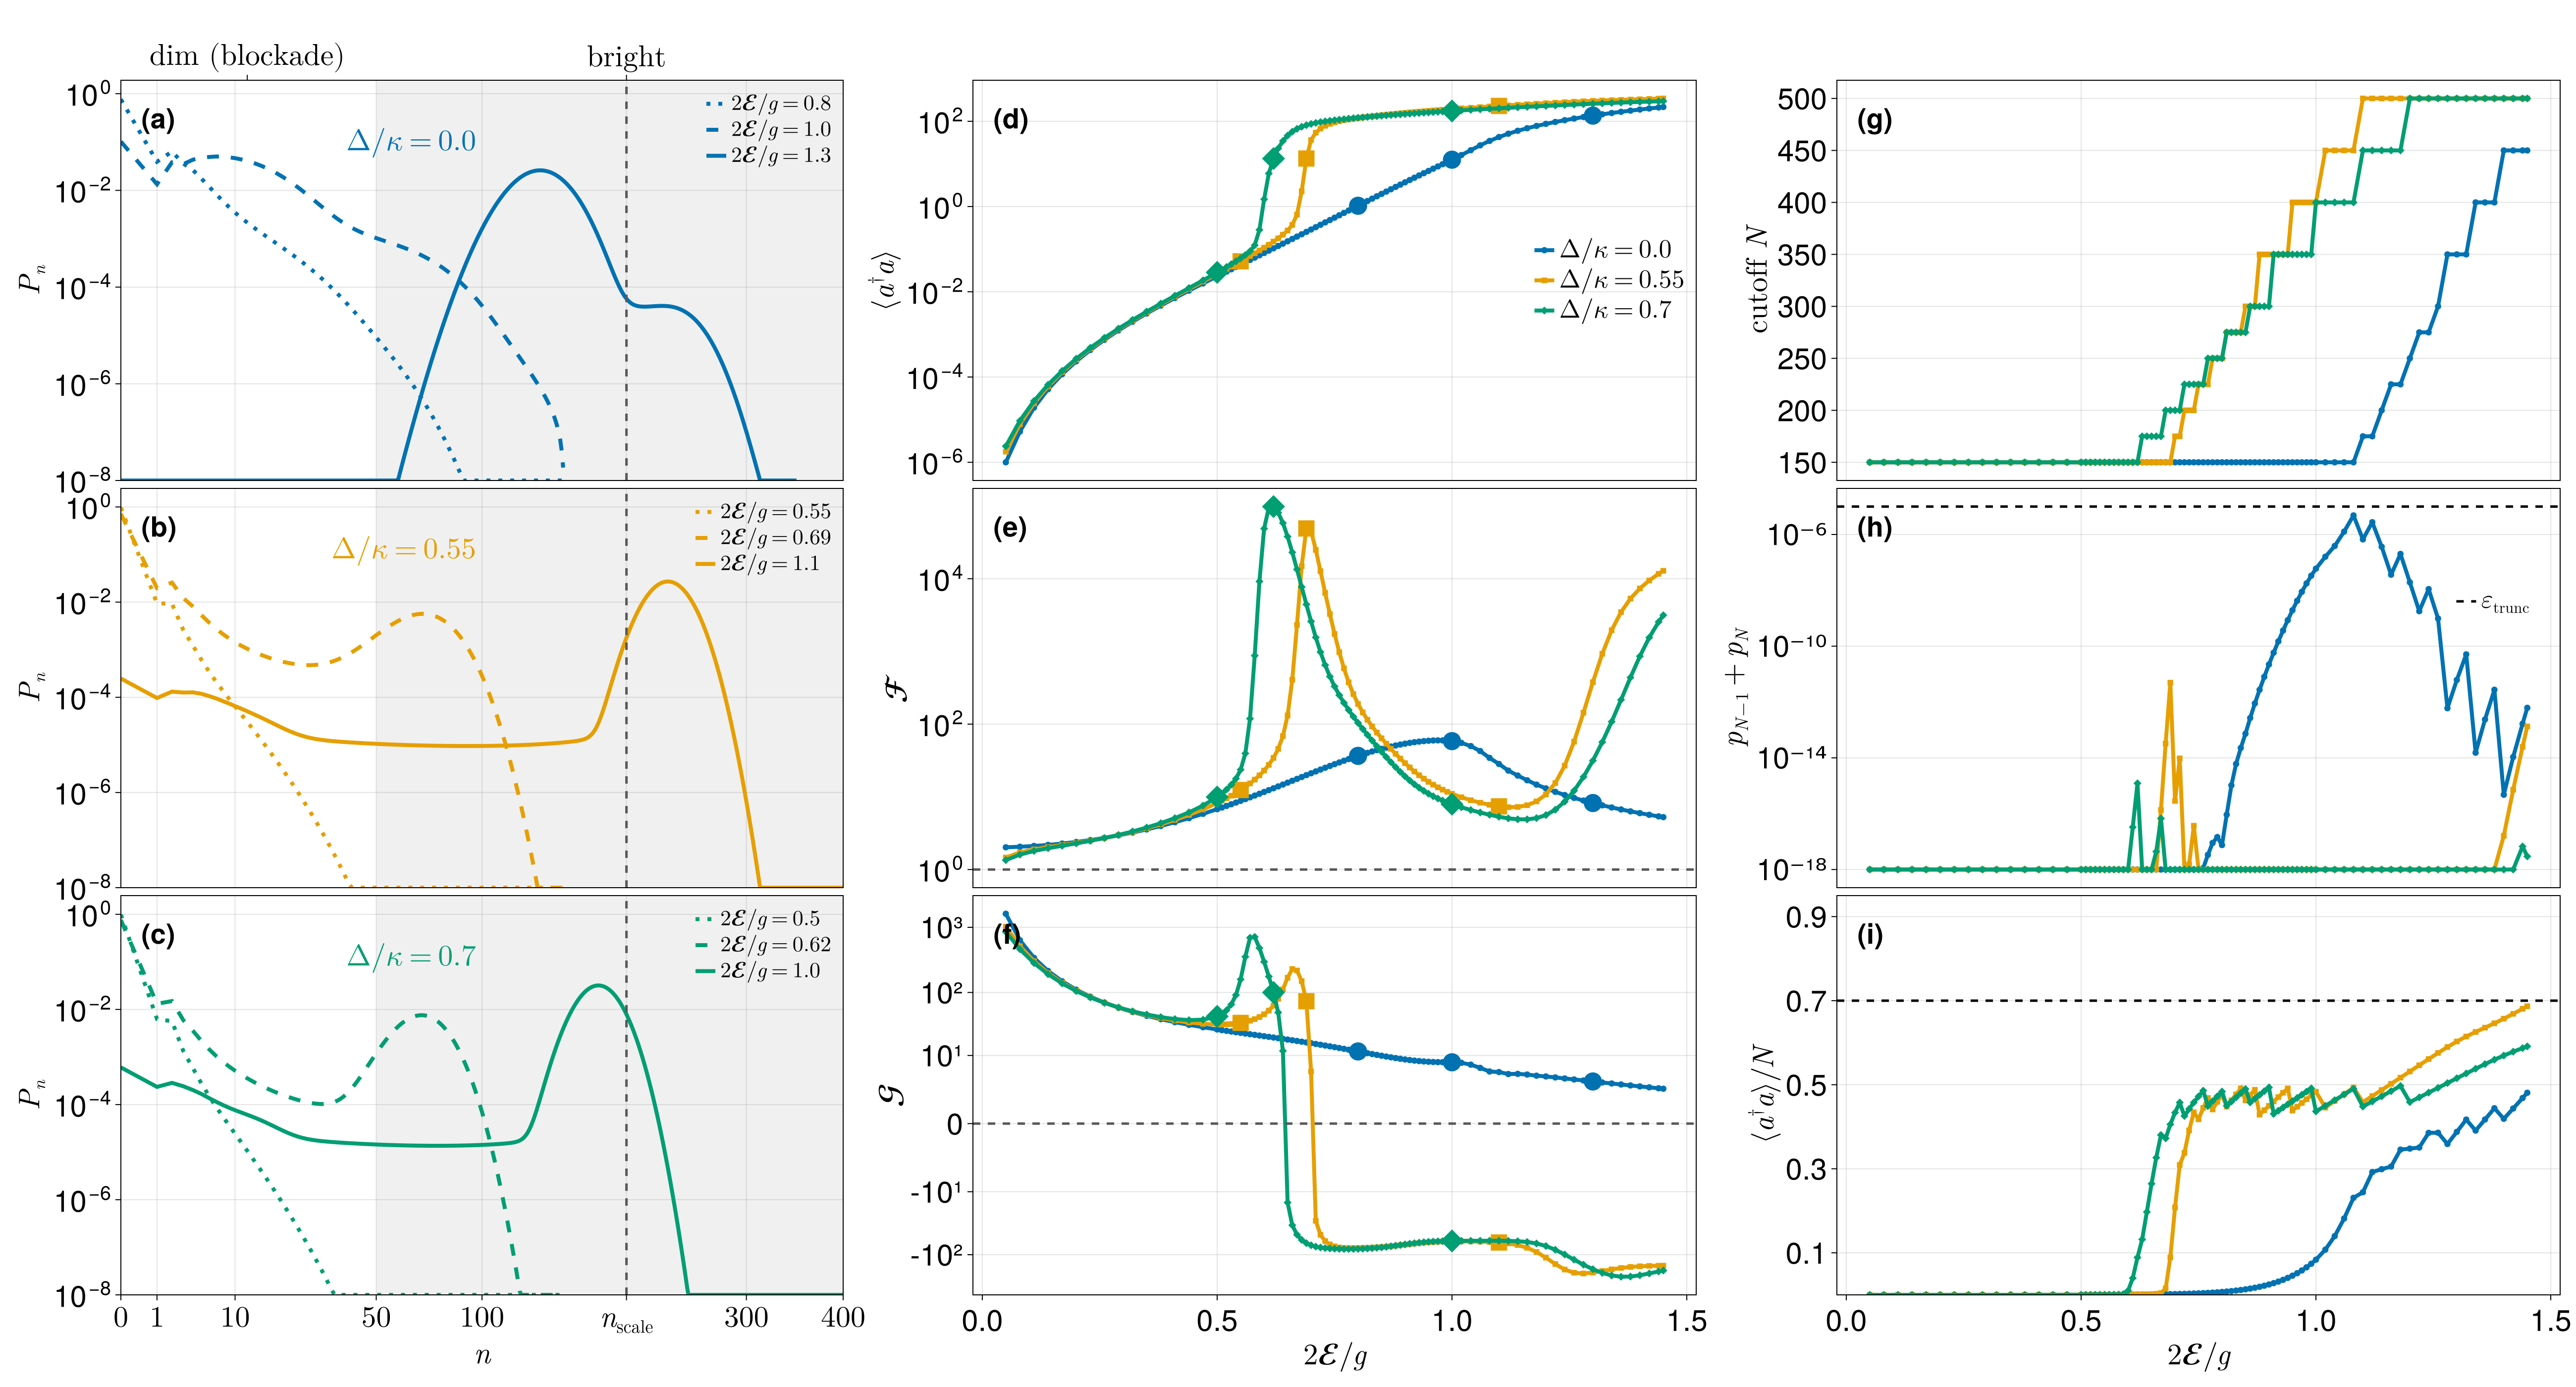

In [9]:
fig2 = jc_paper_figure(rows, production.detuning_cuts, production.fock; g = production.g, κ = κ)
save(projectdir("figures", "jc_fcs_g14.png"), fig2; px_per_unit = 2)
fig2

## Numerical reliability

The diagnostics in panels (g-i) are recorded per point during the sweep, so the
figure and the audit come from the same run. Three quantities matter:

* `current_check` $= c_1/(\kappa\langle a^\dagger a\rangle)$ — the acceptance
  gate; must be 1 to within $10^{-4}$;
* `cavity_tail` $= p_{N-1}+p_N$ — boundary population, the *conventional*
  truncation diagnostic;
* `occupation_fraction` $= \langle a^\dagger a\rangle/N$ — how far up the
  truncated ladder the state actually sits.

In [10]:
audit = DataFrame(
    Δ                   = [r.Δ for r in rows],
    N                   = [r.N for r in rows],
    current_check_error = [abs(r.current_check - 1) for r in rows],
    cavity_tail         = [r.cavity_tail for r in rows],
    occupation_fraction = [r.occupation_fraction for r in rows],
    fcs_retry           = [r.fcs_retry for r in rows],
    cutoff_status       = [String(r.cutoff_status) for r in rows],
)

summary = combine(groupby(audit, :Δ),
    nrow                             => :points,
    :current_check_error => maximum  => :worst_identity_error,
    :cavity_tail         => maximum  => :worst_boundary_tail,
    :occupation_fraction => maximum  => :worst_occupation,
    :fcs_retry           => sum      => :retries,
    :cutoff_status => (v -> count(!=("safe"), v)) => :non_safe_cutoffs,
)
println("Per-cut reliability summary:")
summary

Per-cut reliability summary:


Row,Δ,points,worst_identity_error,worst_boundary_tail,worst_occupation,retries,non_safe_cutoffs
,Float64,Int64,Float64,Float64,Float64,Int64,Int64
1,0.0,89,2.66454e-15,4.81974e-6,0.480908,0,0
2,0.55,89,1.9984e-15,4.93728e-12,0.686782,0,0
3,0.7,89,2.44249e-15,1.22665e-15,0.591287,0,0


### Why the tail is not enough

In the coexistence region the boundary population can sit far below any
sensible threshold while the steady state has still collapsed onto the wrong
branch — the truncated ladder simply cannot host the bright state, and nothing
about $p_{N-1}+p_N$ reveals it.

The honest check is **cross-cutoff agreement of the cumulants**. Below we
recompute a point at successively larger cutoffs and watch the cumulants (not
the tail) settle. `c₃` converges last, which is why the scheduler buys extra
headroom for it.

In [11]:
x_conv, Δ_conv = 0.60, 0.55
conv = NamedTuple[]

for N in (100, 150, 200, 250)
    r = run_jc_fcs_production_sweep(; detuning_cuts = [Δ_conv], x_values = [x_conv],
                                      g = g, κ = κ, nC = 3, N_override = N,
                                      verbose = false)[1]
    push!(conv, (; N, n = r.n, c1 = r.c1, c2 = r.c2, c3 = r.c3,
                   tail = r.cavity_tail, identity_error = abs(r.current_check - 1)))
end

conv_df = DataFrame(conv)
conv_df.c1_rel_change = [missing; [abs(conv_df.c1[i]/conv_df.c1[i-1] - 1) for i in 2:nrow(conv_df)]]
conv_df.c2_rel_change = [missing; [abs(conv_df.c2[i]/conv_df.c2[i-1] - 1) for i in 2:nrow(conv_df)]]
conv_df.c3_rel_change = [missing; [abs(conv_df.c3[i]/conv_df.c3[i-1] - 1) for i in 2:nrow(conv_df)]]
println("Cross-cutoff convergence at Δ/κ = $(Δ_conv), x = $(x_conv):")
conv_df

Cross-cutoff convergence at Δ/κ = 0.55, x = 0.6:


Row,N,n,c1,c2,c3,tail,identity_error,c1_rel_change,c2_rel_change,c3_rel_change
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?,Float64?,Float64?
1,100,0.108541,0.108541,2.49609,181.038,0.0,2.22045e-16,missing,missing,missing
2,150,0.108541,0.108541,2.49609,181.041,0.0,0.0,5.99042e-8,1.8406e-6,1.74358e-5
3,200,0.108541,0.108541,2.49609,181.043,1.10774e-44,8.88178e-16,3.4712e-8,1.0026e-6,1.05067e-5
4,250,0.108541,0.108541,2.49609,181.041,0.0,0.0,2.81417e-8,8.41528e-7,8.406e-6


Two things to read off this table.

First, the cumulants converge at very different rates. Going up one cutoff step
moves $c_1$ by $\sim\!10^{-8}$, $c_2$ by $\sim\!10^{-6}$, and $c_3$ by
$\sim\!10^{-5}$ — roughly two orders of magnitude between the first and third
cumulant. That ordering is why the scheduler buys headroom aimed at $c_3$: a
cutoff that has clearly converged the count rate has *not* necessarily
converged the skewness.

Second — and this is the point — the boundary tail $p_{N-1}+p_N$ is already at
(or indistinguishable from) zero for every cutoff in the table, while $c_3$ is
still moving. The conventional truncation diagnostic reports "fully converged"
throughout. Had we trusted it, we would have stopped at the smallest cutoff and
quietly carried a $10^{-5}$ bias in the skewness. Only the cross-cutoff
comparison exposes that, which is why it is the gauge used in the manuscript.

## Deep dive: probing truncation fragility (optional)

`src/jc_diagnostics.jl` holds the reliability studies used while developing the
numerics, beyond what the manuscript figure reports:

* `run_jc_bright_tail_audit` — records the full $P_n$ profile at risky points
  and re-solves them at higher cutoffs;
* `run_jc_steady_scout` / `jc_scout_convergence` — a cheap cutoff scout;
* `run_jc_steady_continuation_scan` — the continuation scan over $(g/\kappa,
  \Delta/\kappa)$;
* `run_jc_f32_cutoff_rescout` — a single-precision cross-check that makes very
  large cutoffs affordable.

These are off by default because they are slower than the rest of the notebook.

In [ ]:
RUN_JC_DEEP_DIVE = false     # ← set true to run the truncation deep dive

if RUN_JC_DEEP_DIVE
    include(srcdir("jc_diagnostics.jl"))
    scout = run_jc_steady_scout(
        [(label = "bright edge", g = g, E = 0.60 * g / 2, Δ = 0.55)],
        (100, 150, 200, 250))
    display(jc_scout_convergence(scout))
else
    println("Deep dive skipped. Set RUN_JC_DEEP_DIVE = true to run it.")
end